# Modelo actual de clones de código en Python

En este notebook construimos nuestro modelo actual con dos capas:

- Capa 1 léxica con TF-IDF, similitudes y Baker.
- Capa 2 estructural con AST reducido.
- Clasificación con Random Forest.

El objetivo principal es detectar mejor los clones tipo III y IV.


## 1) Configuracion e imports
En esta etapa dejamos listas las librerias que vamos a usar en todo el flujo.
Tambien dejamos una semilla fija para que los resultados se puedan repetir.
Esta ya es la base final del modelo actual.


In [45]:
# Librerias base para carga, preprocesamiento, features y modelado
from pathlib import Path
from typing import Any, Iterable
from difflib import SequenceMatcher
import io
import random
import re
import tokenize
import ast
import keyword

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display


In [46]:
# Configuración global para reproducibilidad
SEED = 42

import warnings
warnings.filterwarnings('ignore', category=SyntaxWarning)

random.seed(SEED)
np.random.seed(SEED)

print('SEED:', SEED)


SEED: 42


## 2) Dataset y reconstruccion de pares
Aqui leemos las carpetas T1, T2, T3 y T4 del dataset.
Cada archivo trae dos snippets y los convertimos a filas de trabajo.
Con esto formamos la tabla principal que alimenta el modelo.


In [47]:
# Rutas fijas del proyecto (supuesto: estructura correcta siempre disponible)
RUTA_BASE = Path.cwd()
RUTA_DATASET = RUTA_BASE / 'DataBaseProject' if (RUTA_BASE / 'DataBaseProject').exists() else RUTA_BASE
RUTA_PARES = RUTA_DATASET / 'pares_clones'

PATRON_SEPARADOR_SNIPPETS = re.compile(r'\n\s*\n\s*\n+')
PATRON_ESPACIOS = re.compile(r'[ \t]+')
PATRON_SALTOS = re.compile(r'\n{3,}')

TIPOS_CLON = ['T1', 'T2', 'T3', 'T4']
TIPO_A_CLASE = {
    'T1': 'type_I',
    'T2': 'type_II',
    'T3': 'type_III',
    'T4': 'type_IV',
}
TIPO_A_GRUPO = {
    'T1': 'pares_t1',
    'T2': 'pares_t2',
    'T3': 'pares_t3',
    'T4': 'pares_t4',
}

COLUMNAS_PARES = [
    'is_clone', 'clone_type', 'source_group', 'filename', 'file_path',
    'problem_id', 'snippet_index_a', 'snippet_index_b',
    'resolved_path', 'snippet_count', 'code_a', 'code_b'
]

def separar_snippets(texto_archivo: str) -> list[str]:
    texto = texto_archivo.replace('\r\n', '\n').replace('\r', '\n').strip()
    return [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]

def cargar_pares_desde_carpetas(ruta_pares: Path) -> pd.DataFrame:
    filas = []
    for tipo in TIPOS_CLON:
        carpeta_tipo = ruta_pares / tipo
        for archivo in sorted(carpeta_tipo.glob('*.py')):
            texto = archivo.read_text(encoding='utf-8', errors='replace')
            snippets = separar_snippets(texto)
            problem_id = int(archivo.stem.split('_')[1])
            filas.append({
                'is_clone': 1,
                'clone_type': TIPO_A_CLASE[tipo],
                'source_group': TIPO_A_GRUPO[tipo],
                'filename': archivo.name,
                'file_path': str(archivo.relative_to(RUTA_DATASET)).replace('/', '\\'),
                'problem_id': problem_id,
                'snippet_index_a': 0,
                'snippet_index_b': 1,
                'resolved_path': str(archivo),
                'snippet_count': len(snippets),
                'code_a': snippets[0],
                'code_b': snippets[1],
            })
    return pd.DataFrame(filas, columns=COLUMNAS_PARES)


In [48]:
# Carga de pares del dataset
datos_reconstruidos = cargar_pares_desde_carpetas(RUTA_PARES)

resumen_reconstruccion = {
    'reconstructed_rows': int(len(datos_reconstruidos)),
    'num_problem_id': int(datos_reconstruidos['problem_id'].nunique()),
    'tipos': datos_reconstruidos['clone_type'].value_counts().to_dict(),
}

print('Filas reconstruidas:', len(datos_reconstruidos))
print('Resumen reconstruccion:', resumen_reconstruccion)


Filas reconstruidas: 8400
Resumen reconstruccion: {'reconstructed_rows': 8400, 'num_problem_id': 2100, 'tipos': {'type_I': 2100, 'type_II': 2100, 'type_III': 2100, 'type_IV': 2100}}


## 3) Preprocesamiento
En esta etapa limpiamos texto de codigo y armamos tokens.
El objetivo es que todos los pares se comparen con el mismo formato.
Esto facilita las metricas de similitud de la capa lexica.


In [49]:
def quitar_comentarios(codigo: str) -> str:
    # Quita comentarios de linea tipo # ...
    lineas = codigo.expandtabs(4).splitlines()
    limpias = []
    for ln in lineas:
        parte = ln.split('#', 1)[0]
        limpias.append(parte)
    return '\n'.join(limpias)


def normalizar_espacios(codigo: str) -> str:
    lineas = [PATRON_ESPACIOS.sub(' ', linea).rstrip() for linea in codigo.splitlines()]
    normalizado = '\n'.join(lineas).strip()
    return PATRON_SALTOS.sub('\n\n', normalizado)


def preprocesar_codigo(codigo: str) -> str:
    return normalizar_espacios(quitar_comentarios(codigo))


def tokenizar_python(codigo: str) -> list[str]:
    # Tokenizacion simple por regex, suficiente para la capa lexica
    patron = r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[][(){}.,:;+*/%=<>-]'
    return re.findall(patron, codigo)


def preparar_campos_par(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['code_a_clean'] = [preprocesar_codigo(x) for x in out['code_a'].astype(str)]
    out['code_b_clean'] = [preprocesar_codigo(x) for x in out['code_b'].astype(str)]
    out['tokens_a'] = [tokenizar_python(x) for x in out['code_a_clean']]
    out['tokens_b'] = [tokenizar_python(x) for x in out['code_b_clean']]
    out['token_text_a'] = [' '.join(t) for t in out['tokens_a']]
    out['token_text_b'] = [' '.join(t) for t in out['tokens_b']]
    return out


datos_preparados = preparar_campos_par(datos_reconstruidos)
print('Filas listas para modelado:', len(datos_preparados))


Filas listas para modelado: 8400


## 4) Capa 1 lexica
Aqui calculamos similitud por tokens y por TF-IDF.
Tambien agregamos Baker simplificado para capturar bloques similares.
Esta capa captura parecido textual y cambios de nombres/literales.


In [50]:
def similitud_jaccard(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a, set_b = set(tokens_a), set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    if not union:
        return 0.0
    return float(len(set_a & set_b) / len(union))


def similitud_dice(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a, set_b = set(tokens_a), set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    denom = len(set_a) + len(set_b)
    if denom == 0:
        return 0.0
    return float(2.0 * len(set_a & set_b) / denom)


def ratio_overlap(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a, set_b = set(tokens_a), set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    min_size = min(len(set_a), len(set_b))
    if min_size == 0:
        return 0.0
    return float(len(set_a & set_b) / min_size)


def ajustar_tfidf(df_train: pd.DataFrame) -> TfidfVectorizer:
    corpus = pd.concat([df_train['token_text_a'], df_train['token_text_b']], axis=0)
    vector = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=1,
    )
    vector.fit(corpus)
    return vector


def coseno_fila_a_fila(mat_a: sparse.spmatrix, mat_b: sparse.spmatrix) -> np.ndarray:
    # Producto punto por fila dividido por norma por fila
    producto = np.asarray(mat_a.multiply(mat_b).sum(axis=1)).ravel()
    norma_a = np.sqrt(np.asarray(mat_a.multiply(mat_a).sum(axis=1)).ravel())
    norma_b = np.sqrt(np.asarray(mat_b.multiply(mat_b).sum(axis=1)).ravel())
    denom = norma_a * norma_b
    denom[denom == 0.0] = 1e-12
    return producto / denom


def construir_features_lexicas_base(df: pd.DataFrame, vector: TfidfVectorizer) -> pd.DataFrame:
    mat_a = vector.transform(df['token_text_a'])
    mat_b = vector.transform(df['token_text_b'])

    chars_a = df['code_a_clean'].str.len().astype(float)
    chars_b = df['code_b_clean'].str.len().astype(float)
    toks_a = df['tokens_a'].apply(len).astype(float)
    toks_b = df['tokens_b'].apply(len).astype(float)

    return pd.DataFrame({
        'lex_cosine_tfidf': coseno_fila_a_fila(mat_a, mat_b),
        'lex_jaccard_tokens': [similitud_jaccard(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])],
        'lex_dice_tokens': [similitud_dice(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])],
        'lex_overlap_tokens': [ratio_overlap(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])],
        'len_chars_a': chars_a,
        'len_chars_b': chars_b,
        'len_chars_diff_abs': (chars_a - chars_b).abs(),
        'len_tokens_a': toks_a,
        'len_tokens_b': toks_b,
        'len_tokens_diff_abs': (toks_a - toks_b).abs(),
    }, index=df.index)


def baker_tokenizar_generalizar(codigo: str) -> list[str]:
    # Version simple: identificadores, numeros y operadores
    tokens = re.findall(r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[][(){}.,:;+*/%=<>-]', codigo)
    out = []
    for t in tokens:
        if re.fullmatch(r'[A-Za-z_]\w*', t):
            out.append(t if keyword.iskeyword(t) else 'ID')
        elif re.fullmatch(r'\d+', t):
            out.append('NUM')
        else:
            out.append(t)
    return out


def baker_features_par(codigo_a: str, codigo_b: str, min_match_len: int = 3) -> dict[str, float]:
    ta = baker_tokenizar_generalizar(codigo_a)
    tb = baker_tokenizar_generalizar(codigo_b)

    if len(ta) == 0 or len(tb) == 0:
        return {
            'baker_match_total_ratio': 0.0,
            'baker_match_max_ratio': 0.0,
            'baker_num_blocks': 0.0,
        }

    matcher = SequenceMatcher(a=ta, b=tb, autojunk=False)
    blocks = [b for b in matcher.get_matching_blocks() if b.size >= min_match_len]
    total_match = float(sum(b.size for b in blocks))
    max_match = float(max([b.size for b in blocks], default=0.0))

    base = float(min(len(ta), len(tb)))
    return {
        'baker_match_total_ratio': total_match / base,
        'baker_match_max_ratio': max_match / base,
        'baker_num_blocks': float(len(blocks)),
    }


def construir_features_baker(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    rows = [
        baker_features_par(a, b, min_match_len=min_match_len)
        for a, b in zip(df['code_a_clean'], df['code_b_clean'])
    ]
    return pd.DataFrame(rows, index=df.index)


def construir_features_modelo_capa1(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3) -> pd.DataFrame:
    fx_lex = construir_features_lexicas_base(df, vector)
    fx_baker = construir_features_baker(df, min_match_len=min_match_len)
    return pd.concat([fx_lex, fx_baker], axis=1)


## 5) Capa 2 AST y vector final
En esta etapa extraemos rasgos sintacticos con AST.
Luego unimos capa lexica + capa AST para formar el vector final.
Ese vector es la entrada directa al clasificador.


In [51]:
AST_METRIC_KEYS = [
    'ast_total_nodes',
    'ast_depth',
    'ast_num_functions',
    'ast_num_loops',
    'ast_num_ifs',
    'ast_num_calls',
    'ast_num_imports',
]


def _profundidad_max_bloques(codigo: str) -> float:
    max_depth = 0.0
    for ln in codigo.expandtabs(4).splitlines():
        if not ln.strip():
            continue
        depth = float((len(ln) - len(ln.lstrip(' '))) // 4)
        if depth > max_depth:
            max_depth = depth
    return max_depth


def extraer_features_ast_snippet(codigo: str) -> dict[str, Any]:
    # Version estructural estable: usa patrones de sintaxis, no parseo estricto
    codigo_ok = codigo if codigo.strip() else 'pass'
    lineas = codigo_ok.expandtabs(4).splitlines()

    num_functions = sum(1 for ln in lineas if re.match(r'^\s*(async\s+def|def)\s+', ln))
    num_loops = sum(1 for ln in lineas if re.match(r'^\s*(for|while)\s+', ln))
    num_ifs = sum(1 for ln in lineas if re.match(r'^\s*if\s+', ln))
    num_imports = sum(1 for ln in lineas if re.match(r'^\s*(import|from)\s+', ln))

    # Llamadas aproximadas: nombre(...
    llamadas = re.findall(r'[A-Za-z_]\w*\s*\(', codigo_ok)
    num_calls = float(len(llamadas))

    # Conteo de tipos estructurales aproximados
    type_counts = {
        'FunctionDef': int(num_functions),
        'Loop': int(num_loops),
        'If': int(num_ifs),
        'Call': int(num_calls),
        'Import': int(num_imports),
    }

    # Total nodos aproximado: cantidad de tokens
    total_nodes = float(len(tokenizar_python(codigo_ok)))

    return {
        'ast_total_nodes': total_nodes,
        'ast_depth': _profundidad_max_bloques(codigo_ok),
        'ast_num_functions': float(num_functions),
        'ast_num_loops': float(num_loops),
        'ast_num_ifs': float(num_ifs),
        'ast_num_calls': num_calls,
        'ast_num_imports': float(num_imports),
        'ast_type_counts': type_counts,
    }


def _diff_rel(a: float, b: float, eps: float = 1e-9) -> float:
    # Diferencia relativa: divide por el valor de mayor escala
    denom = max(abs(float(a)), abs(float(b)), eps)
    return abs(float(a) - float(b)) / denom


def _jaccard_keys(d1: dict[str, int], d2: dict[str, int]) -> float:
    k1, k2 = set(d1.keys()), set(d2.keys())
    if not k1 and not k2:
        return 1.0
    union = k1 | k2
    if not union:
        return 0.0
    return float(len(k1 & k2) / len(union))


def _weighted_overlap_counts(d1: dict[str, int], d2: dict[str, int]) -> float:
    keys = set(d1.keys()) | set(d2.keys())
    if not keys:
        return 1.0
    num = 0.0
    den = 0.0
    for k in keys:
        a = float(d1.get(k, 0))
        b = float(d2.get(k, 0))
        num += min(a, b)
        den += max(a, b)
    if den == 0.0:
        return 0.0
    return num / den


def construir_features_ast_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_features_ast_snippet(x) for x in df['code_a_clean']]
    fx_b = [extraer_features_ast_snippet(x) for x in df['code_b_clean']]

    filas = []
    for a, b in zip(fx_a, fx_b):
        fila = {}
        for k in AST_METRIC_KEYS:
            fila[f'{k}_a'] = float(a[k])
            fila[f'{k}_b'] = float(b[k])
            fila[f'{k}_diff_abs'] = abs(float(a[k]) - float(b[k]))
            fila[f'{k}_diff_rel'] = _diff_rel(float(a[k]), float(b[k]))

        fila['ast_type_jaccard_keys'] = _jaccard_keys(a['ast_type_counts'], b['ast_type_counts'])
        fila['ast_type_weighted_overlap'] = _weighted_overlap_counts(a['ast_type_counts'], b['ast_type_counts'])
        filas.append(fila)

    return pd.DataFrame(filas, index=df.index)


def seleccionar_ast_reducido(df_ast: pd.DataFrame) -> pd.DataFrame:
    cols = [
        'ast_total_nodes_diff_rel',
        'ast_depth_diff_rel',
        'ast_num_functions_diff_rel',
        'ast_num_loops_diff_rel',
        'ast_num_ifs_diff_rel',
        'ast_num_calls_diff_rel',
        'ast_type_jaccard_keys',
        'ast_type_weighted_overlap',
    ]
    return df_ast[cols].copy()


def construir_features_modelo(df: pd.DataFrame, vector_tfidf: TfidfVectorizer, min_match_len: int = 3, ast_variant: str = 'reduced') -> pd.DataFrame:
    fx_capa1 = construir_features_modelo_capa1(df, vector_tfidf, min_match_len=min_match_len)
    fx_ast = construir_features_ast_par(df)

    if ast_variant == 'reduced':
        fx_ast_sel = seleccionar_ast_reducido(fx_ast)
    else:
        fx_ast_sel = fx_ast

    return pd.concat([fx_capa1, fx_ast_sel], axis=1)


## 6) Split por problem_id
Separamos train, val y test por grupos (problem_id).
Asi evitamos fuga de informacion entre snippets del mismo problema.
Este paso es clave para una evaluacion realista.


Estadisticas split del modelo:
{'split': 'test', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}
{'split': 'train', 'rows': 5880, 'unique_groups': 1470, 'class_distribution': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}}
{'split': 'val', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}


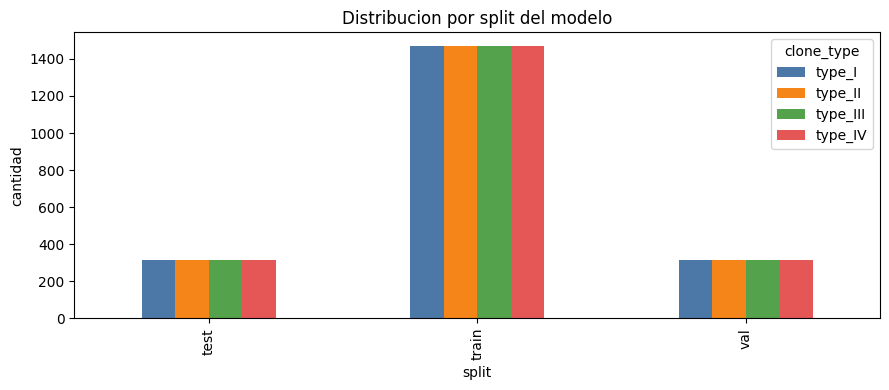

In [52]:
def split_por_grupo(
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
    seed: int = 42,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
):
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp

    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    idx_train = df.index[idx_train_np]
    idx_val = df_temp.index[idx_val_rel]
    idx_test = df_temp.index[idx_test_rel]
    return idx_train, idx_val, idx_test


def asignar_split(df, idx_train, idx_val, idx_test, nombre_columna='split'):
    datos = df.copy()
    datos[nombre_columna] = 'unassigned'
    datos.loc[idx_train, nombre_columna] = 'train'
    datos.loc[idx_val, nombre_columna] = 'val'
    datos.loc[idx_test, nombre_columna] = 'test'
    return datos


def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    resumen = []
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append({
            'split': nombre_split,
            'rows': int(len(df_split)),
            'unique_groups': int(df_split[group_col].nunique()),
            'class_distribution': {str(k): int(v) for k, v in conteos.items()},
        })
    return resumen


def balancear_train(df_train: pd.DataFrame, target_col: str, estrategia: str = 'none', seed: int = 42):
    conteos = df_train[target_col].value_counts()
    info = {
        'strategy': estrategia,
        'target_col': target_col,
        'rows_before': int(len(df_train)),
        'class_distribution_before': {str(k): int(v) for k, v in conteos.items()},
    }

    if estrategia == 'none' or len(conteos) <= 1:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    if estrategia == 'undersample':
        n_obj = int(conteos.min())
        rep = False
    elif estrategia == 'oversample':
        n_obj = int(conteos.max())
        rep = True
    else:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    partes = []
    for clase in conteos.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=n_obj, replace=rep, random_state=seed))

    out = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    c2 = out[target_col].value_counts()
    info['rows_after'] = int(len(out))
    info['class_distribution_after'] = {str(k): int(v) for k, v in c2.items()}
    return out, info


idx_train, idx_val, idx_test = split_por_grupo(
    df=datos_preparados,
    group_col='problem_id',
    target_col='clone_type',
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)


datos_modelo = asignar_split(datos_preparados, idx_train, idx_val, idx_test)

print('Estadisticas split del modelo:')
stats_modelo = estadisticas_split(datos_modelo, 'split', 'clone_type', 'problem_id')
for fila in stats_modelo:
    print(fila)

conteos_split = datos_modelo.groupby(['split', 'clone_type']).size().unstack(fill_value=0)
conteos_split.plot(kind='bar', figsize=(9, 4), color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title('Distribucion por split del modelo')
plt.xlabel('split')
plt.ylabel('cantidad')
plt.tight_layout()
plt.show()


## 7) Entrenamiento del modelo
Entrenamos Random Forest con el vector final de features.
Evaluamos en validacion y test para medir desempeno general.
Esta ya es la configuracion final del modelo actual.


--- configuracion del modelo actual ---
modelo: random_forest
ast_variant: reduced
num_features: 21

--- balanceo train ---
{'strategy': 'undersample', 'target_col': 'clone_type', 'rows_before': 5880, 'class_distribution_before': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}, 'rows_after': 5880, 'class_distribution_after': {'type_IV': 1470, 'type_III': 1470, 'type_I': 1470, 'type_II': 1470}}

--- metricas test ---
accuracy: 0.9198
precision_macro: 0.9201
recall_macro: 0.9198
f1_macro: 0.9197


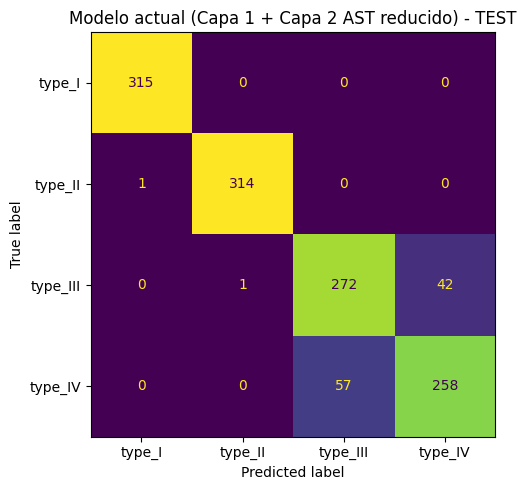

In [53]:
# Configuracion del entrenamiento
ESTRATEGIA_BALANCEO = 'undersample'
MIN_MATCH_LEN_BAKER = 3
AST_VARIANT_OFICIAL = 'reduced'
MODELO_CLASIFICADOR = 'random_forest'


def evaluar_predicciones(y_true, y_pred, labels: list) -> dict[str, Any]:
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    reporte_texto = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    return {
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_w),
        'recall_weighted': float(r_w),
        'f1_weighted': float(f1_w),
        'confusion_matrix': cm.tolist(),
        'classification_report_dict': reporte_dict,
        'classification_report_text': reporte_texto,
    }


def entrenar_evaluar_modelo_actual(
    datos_task,
    columna_target,
    etiquetas,
    seed,
    estrategia_balanceo='none',
    min_match_len=3,
    ast_variant='reduced',
):
    train_raw = datos_task[datos_task['split'] == 'train'].copy()
    val = datos_task[datos_task['split'] == 'val'].copy()
    test = datos_task[datos_task['split'] == 'test'].copy()

    train_balanceado, info_balanceo = balancear_train(train_raw, columna_target, estrategia_balanceo, seed)

    vector_tfidf = ajustar_tfidf(train_balanceado)
    X_train = construir_features_modelo(train_balanceado, vector_tfidf, min_match_len=min_match_len, ast_variant=ast_variant)
    X_val = construir_features_modelo(val, vector_tfidf, min_match_len=min_match_len, ast_variant=ast_variant)
    X_test = construir_features_modelo(test, vector_tfidf, min_match_len=min_match_len, ast_variant=ast_variant)

    modelo = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=seed,
        n_jobs=-1,
    )
    modelo.fit(X_train, train_balanceado[columna_target])

    y_val = val[columna_target]
    y_test = test[columna_target]
    pred_val = modelo.predict(X_val)
    pred_test = modelo.predict(X_test)

    metricas_val = evaluar_predicciones(y_val, pred_val, labels=etiquetas)
    metricas_test = evaluar_predicciones(y_test, pred_test, labels=etiquetas)

    return {
        'info_balanceo': info_balanceo,
        'metricas_val': metricas_val,
        'metricas_test': metricas_test,
        'modelo': modelo,
        'feature_names': X_train.columns.tolist(),
        'num_features': int(X_train.shape[1]),
    }


def graficar_matriz_confusion(resultado: dict, etiquetas: list[str], titulo: str):
    cm = np.array(resultado['metricas_test']['confusion_matrix'])
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=[str(x) for x in etiquetas]).plot(ax=ax, colorbar=False)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


etiquetas_modelo = sorted(datos_modelo['clone_type'].unique().tolist())

resultado_modelo_actual = entrenar_evaluar_modelo_actual(
    datos_task=datos_modelo,
    columna_target='clone_type',
    etiquetas=etiquetas_modelo,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    min_match_len=MIN_MATCH_LEN_BAKER,
    ast_variant=AST_VARIANT_OFICIAL,
)

print('--- configuracion del modelo actual ---')
print('modelo:', MODELO_CLASIFICADOR)
print('ast_variant:', AST_VARIANT_OFICIAL)
print('num_features:', resultado_modelo_actual['num_features'])
print('')
print('--- balanceo train ---')
print(resultado_modelo_actual['info_balanceo'])
print('')
print('--- metricas test ---')
print('accuracy:', round(resultado_modelo_actual['metricas_test']['accuracy'], 4))
print('precision_macro:', round(resultado_modelo_actual['metricas_test']['precision_macro'], 4))
print('recall_macro:', round(resultado_modelo_actual['metricas_test']['recall_macro'], 4))
print('f1_macro:', round(resultado_modelo_actual['metricas_test']['f1_macro'], 4))

graficar_matriz_confusion(
    resultado_modelo_actual,
    etiquetas_modelo,
    'Modelo actual (Capa 1 + Capa 2 AST reducido) - TEST',
)


## 8) Evaluacion e interpretacion
Mostramos metricas globales y metricas por clase.
Ponemos foco en type_III y type_IV por su mayor dificultad.
Con esto cerramos la version final del pipeline.


In [54]:
resumen_modelo_actual = pd.DataFrame([
    {
        'modelo': MODELO_CLASIFICADOR,
        'ast_variant': AST_VARIANT_OFICIAL,
        'num_features': resultado_modelo_actual['num_features'],
        'accuracy_val': resultado_modelo_actual['metricas_val']['accuracy'],
        'precision_macro_val': resultado_modelo_actual['metricas_val']['precision_macro'],
        'recall_macro_val': resultado_modelo_actual['metricas_val']['recall_macro'],
        'f1_macro_val': resultado_modelo_actual['metricas_val']['f1_macro'],
        'accuracy_test': resultado_modelo_actual['metricas_test']['accuracy'],
        'precision_macro_test': resultado_modelo_actual['metricas_test']['precision_macro'],
        'recall_macro_test': resultado_modelo_actual['metricas_test']['recall_macro'],
        'f1_macro_test': resultado_modelo_actual['metricas_test']['f1_macro'],
    }
])

print('resumen del modelo actual')
display(resumen_modelo_actual)

rep = resultado_modelo_actual['metricas_test']['classification_report_dict']
rows_cls = []
for lbl in etiquetas_modelo:
    rows_cls.append({
        'label': lbl,
        'precision_test': rep[lbl]['precision'],
        'recall_test': rep[lbl]['recall'],
        'f1_test': rep[lbl]['f1-score'],
        'support_test': rep[lbl]['support'],
    })

metricas_por_clase = pd.DataFrame(rows_cls).sort_values('label')
print('metricas por clase en test')
display(metricas_por_clase)

print('foco en type_iii y type_iv')
display(metricas_por_clase[metricas_por_clase['label'].isin(['type_III', 'type_IV'])])


resumen del modelo actual


,modelo,ast_variant,num_features,accuracy_val,precision_macro_val,recall_macro_val,f1_macro_val,accuracy_test,precision_macro_test,recall_macro_test,f1_macro_test
0,random_forest,reduced,21,0.92619,0.926483,0.92619,0.926107,0.919841,0.920102,0.919841,0.919746


metricas por clase en test


,label,precision_test,recall_test,f1_test,support_test
0,type_I,0.996835,1.000000,0.998415,315.0
1,type_II,0.996825,0.996825,0.996825,315.0
2,type_III,0.826748,0.863492,0.844720,315.0
3,type_IV,0.860000,0.819048,0.839024,315.0


foco en type_iii y type_iv


,label,precision_test,recall_test,f1_test,support_test
2,type_III,0.826748,0.863492,0.844720,315.0
3,type_IV,0.860000,0.819048,0.839024,315.0


## 9) Interpretación de resultados

En esta versión oficial usamos:

- Capa 1 léxica + Baker.
- Capa 2 AST reducido.
- Random Forest.

Nos enfocamos en métricas globales y en `type_III` y `type_IV`.


## 10) Siguiente paso del proyecto

Con esta base lista en dos capas, después podemos agregar:

1. Capa de contexto.
2. Capa de embeddings.


## 11) Reflexión final del modelo y resultados obtenidos

En esta etapa dejamos una versión estable del modelo con dos capas:

- Capa 1 léxica con Baker.
- Capa 2 AST reducido.
- Random Forest como clasificador.

Con esta base podemos iterar y optimizar para mejorar la detección de clones complejos.
